## Importações

In [63]:
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, f1_score
# import requests

# df_modelo = pd.read_csv("df_modelo_30dias.csv")

## Verificação do funcionamento do link

In [64]:
# def url_valida(url):
#     if not url.startswith("http"):
#         return False

#     try:
#         resposta = requests.get(url, timeout=5)

#         if resposta.status_code != 200:
#             return False

#         html = resposta.text.lower()

#         erros = [
#             "video unavailable",
#             "vídeo indisponível",
#             "this video is private",
#             "este vídeo é privado",
#             "was removed"
#         ]

#         return not any(erro in html for erro in erros)

#     except:
#         return False

# df_modelo = df_modelo[df_modelo["titulo"].apply(url_valida)]
# df_modelo = df_modelo[df_modelo["proximo_video"].apply(url_valida)]

# print("Número de transições válidas:", len(df_modelo))

## Criação de períodos para ter mais uma coluna de base

In [65]:
# df_modelo["data"] = pd.to_datetime(df_modelo["data"])

# df_modelo["hora"] = df_modelo["data"].dt.hour
# display(df_modelo)
# def periodo_do_dia(hora):
#     if 5 <= hora < 12:
#         return "manhã"
#     elif 12 <= hora < 18:
#         return "tarde"
#     elif 18 <= hora < 24:
#         return "noite"
#     else:
#         return "madrugada"

# df_modelo["periodo"] = df_modelo["hora"].apply(periodo_do_dia)

## Divisão de dados treino e teste para prever o próximo vídeo

In [66]:
# le_titulo = LabelEncoder()
# le_proximo = LabelEncoder()

# df_modelo["titulo_encoded"] = le_titulo.fit_transform(df_modelo["titulo"])
# df_modelo["proximo_encoded"] = le_proximo.fit_transform(df_modelo["proximo_video"])

# le_periodo = LabelEncoder()
# df_modelo["periodo_encoded"] = le_periodo.fit_transform(df_modelo["periodo"])

# X = df_modelo[["titulo_encoded", "periodo_encoded"]]
# y = df_modelo["proximo_encoded"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# modelo = RandomForestClassifier(n_estimators=100, random_state=42)
# modelo.fit(X_train, y_train)

# y_pred = modelo.predict(X_test)
# print("Acurácia:", accuracy_score(y_test, y_pred))
# f1 = f1_score(y_test, y_pred, average='macro')
# print("F1-score:", f1)

## Avaliação das probabilidades e definição dos três melhores vídeos

In [67]:
# def recomendar_top_n(video, periodo, modelo, le_titulo, le_proximo, le_periodo, n=3):

#     if video not in le_titulo.classes_:
#         return []

#     video_enc = le_titulo.transform([video])[0]
#     periodo_enc = le_periodo.transform([periodo])[0]

#     entrada = [[video_enc, periodo_enc]]

#     probs = modelo.predict_proba(entrada)[0]

#     top_n_idx = probs.argsort()[::-1][:n]

#     top_n_links = le_proximo.inverse_transform(top_n_idx)
#     top_n_probs = probs[top_n_idx]

#     return list(zip(top_n_links, top_n_probs))

# video_atual = input("Insira o link do vídeo: ")
# periodo_atual = input("Informe o período (manhã/tarde/noite/madrugada): ")

# top_videos = recomendar_top_n(
#     video_atual,
#     periodo_atual,
#     modelo,
#     le_titulo,
#     le_proximo,
#     le_periodo,
#     n=3
# )

# if top_videos:
#     print("Top 3 próximos vídeos recomendados:")
#     for link, prob in top_videos:
#         print(link, "→", prob)
# else:
#     print("Vídeo não encontrado no modelo.")

In [68]:
# import joblib
# # Salvar o modelo treinado
# joblib.dump(modelo, "modelo_rf.pkl")
# print("Modelo salvo como modelo_rf.pkl")

## Importações

In [77]:
import pandas as pd
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

## Carregando os CSVs

In [86]:
df_likes = pd.read_csv("../database/YT_API/curtidas.csv")
df_inscricoes = pd.read_csv("../database/YT_API/inscricoes.csv")

## Agrupando os dois CSVs pelo "canal_id"

In [81]:
df_canal = df_likes.groupby("canal_id").agg(
    qtd_videos_curtidos=("video_id", "count"),
    media_views=("view_count", "mean")
).reset_index()

## Target de inscrição

In [82]:
canais_inscritos = set(df_inscricoes["canal_id"])

df_canal["inscreveu"] = df_canal["canal_id"].apply(
    lambda x: 1 if x in canais_inscritos else 0
)

## Criação do modelo com base em duas features

In [83]:
# usar só 2 features
X = df_canal[["qtd_videos_curtidos", "media_views"]]
y = df_canal["inscreveu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Acurácia: 0.8837209302325582
F1-score: 0.2857142857142857


## Função que calcula a probabilidade de inscrição

In [ ]:
def prever_inscricao(model, qtd_videos_curtidos, media_views):
    
    entrada = pd.DataFrame([{
        "qtd_videos_curtidos": qtd_videos_curtidos,
        "media_views": media_views
    }])
    
    prob = model.predict_proba(entrada)[0][1]
    
    print(f"Probabilidade de inscrição: {prob:.2f}")
    print("Vai se inscrever?", "Sim" if prob >= 0.5 else "Não")
    
    return prob

## Chamada da função e escolha de valores

In [85]:
curtidos = int(input("Quantidade de vídeos curtidos: "))
views = int(input("Média de visualizações: "))
prever_inscricao(model, curtidos, views)

Probabilidade de inscrição: 0.26
Vai se inscrever? Não


np.float32(0.25817415)

## Feature importance

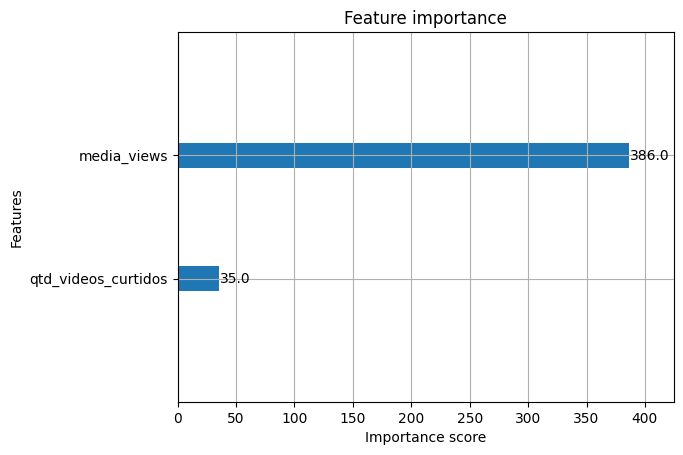

In [72]:
plot_importance(model)
plt.show()